# V62 Crypto: Multi-Year Comparison (2023, 2024, 2025)

Notebook ini membandingkan strategi **AI + Graph (Diversify & Cluster)** terhadap **Static Markowitz** untuk cryptocurrency pada tiap tahun secara individual (2023, 2024, dan 2025).

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import fbeta_score
import random
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load Cryptocurrency Data
file_path = '../experiment_nextLevel2/dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

print(f"Data: {len(data)} rows, {len(data.columns)} assets")
print(f"Period: {data.index[0]} to {data.index[-1]}")

Data: 990 rows, 25 assets
Period: 2023-04-17 00:00:00 to 2025-12-31 00:00:00


In [3]:
# AI Training & Probability Generation for All Years
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

# Split training (2023-2024) - note that 2023/2024 backtests will be in-sample
X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]

# Train XGBoost model
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, 
                              random_state=SEED, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Optimized Threshold dari training data
train_probs = xgb_model.predict_proba(X_train)[:, 1]
opt_t = np.linspace(0.3, 0.7, 41)[np.argmax([fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) 
                                              for t in np.linspace(0.3, 0.7, 41)])]

# Generate probabilitas untuk seluruh dataset
X_all = features.dropna()
all_probs = pd.Series(xgb_model.predict_proba(X_all)[:, 1], index=X_all.index)

print(f"Optimized Threshold: {opt_t:.2f}")

Optimized Threshold: 0.54


In [4]:
# Markowitz & Selection Functions
def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    num_assets = len(mu)
    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets
    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def get_all_assets(returns_window, corr_threshold=None):
    return list(returns_window.columns)

def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    momentum = returns_window.mean()
    assets = list(momentum.sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > corr_threshold:
                G.add_edge(assets[i], assets[j])
    return list(nx.approximation.maximum_independent_set(G))

def get_assets_graph_cluster(returns_window, corr_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    momentum = returns_window.mean()
    assets = list(momentum.sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) < corr_threshold:
                G.add_edge(assets[i], assets[j])
    return list(nx.approximation.maximum_independent_set(G))

In [5]:
# Simulation Functions (AI-Gated & Static)

def run_simulation_ai_gated(test_dates, returns, ai_probs, threshold, market_idx, selection_func, fee=0.0025, g_lookback=60):
    val = 100.0
    history, dates = [val], [test_dates[0]]
    current_weights, risk_status = {}, False
    market_ma = market_index.rolling(window=50).mean()
    
    for i, date in enumerate(test_dates[:-1]):
        prob = ai_probs.loc[date]
        # AI Signal with hysteresis
        ai_signal = prob > (threshold + 0.05) if not risk_status else prob > (threshold - 0.05)
        
        final_signal = ai_signal
        if not ai_signal and market_idx.loc[date] > market_ma.loc[date]: 
            final_signal = True
        
        regime_changed = (final_signal != risk_status)
        risk_status = final_signal
        
        if not risk_status:
            target_weights = {'CASH': 1.0}
        else:
            if regime_changed or i % 20 == 0:
                loc_idx = returns.index.get_loc(date)
                if loc_idx < g_lookback: 
                    target_weights = current_weights
                else:
                    window_rets = returns.iloc[max(0, loc_idx-g_lookback):loc_idx]
                    selected = selection_func(window_rets)
                    target_weights = optimize_markowitz(window_rets[selected])
            else: target_weights = current_weights
        
        all_keys = set(target_weights.keys()) | set(current_weights.keys())
        turnover = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
        val -= val * turnover * fee
        
        next_date = test_dates[i+1]
        day_ret = 0
        if not (target_weights.get('CASH', 0) > 0.99):
            for asset, w in target_weights.items():
                if asset in returns.columns:
                    r = returns.loc[next_date, asset]
                    day_ret += w * (r if not pd.isna(r) else 0)
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = target_weights
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

def run_simulation_static(test_dates, returns, selection_func, fee=0.0025, g_lookback=60):
    val = 100.0
    history, dates = [val], [test_dates[0]]
    current_weights = {}
    for i, date in enumerate(test_dates[:-1]):
        if i % 20 == 0:
            loc_idx = returns.index.get_loc(date)
            if loc_idx >= g_lookback:
                window_rets = returns.iloc[max(0, loc_idx-g_lookback):loc_idx]
                selected = selection_func(window_rets)
                target_weights = optimize_markowitz(window_rets[selected])
            else: target_weights = current_weights
        else: target_weights = current_weights
        
        all_keys = set(target_weights.keys()) | set(current_weights.keys())
        turnover = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
        val -= val * turnover * fee
        next_date = test_dates[i+1]
        day_ret = sum(w * (returns.loc[next_date, a] if not pd.isna(returns.loc[next_date, a]) else 0) for a, w in target_weights.items() if a in returns.columns)
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = target_weights
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

Processing Year: 2023...
Processing Year: 2024...
Processing Year: 2025...


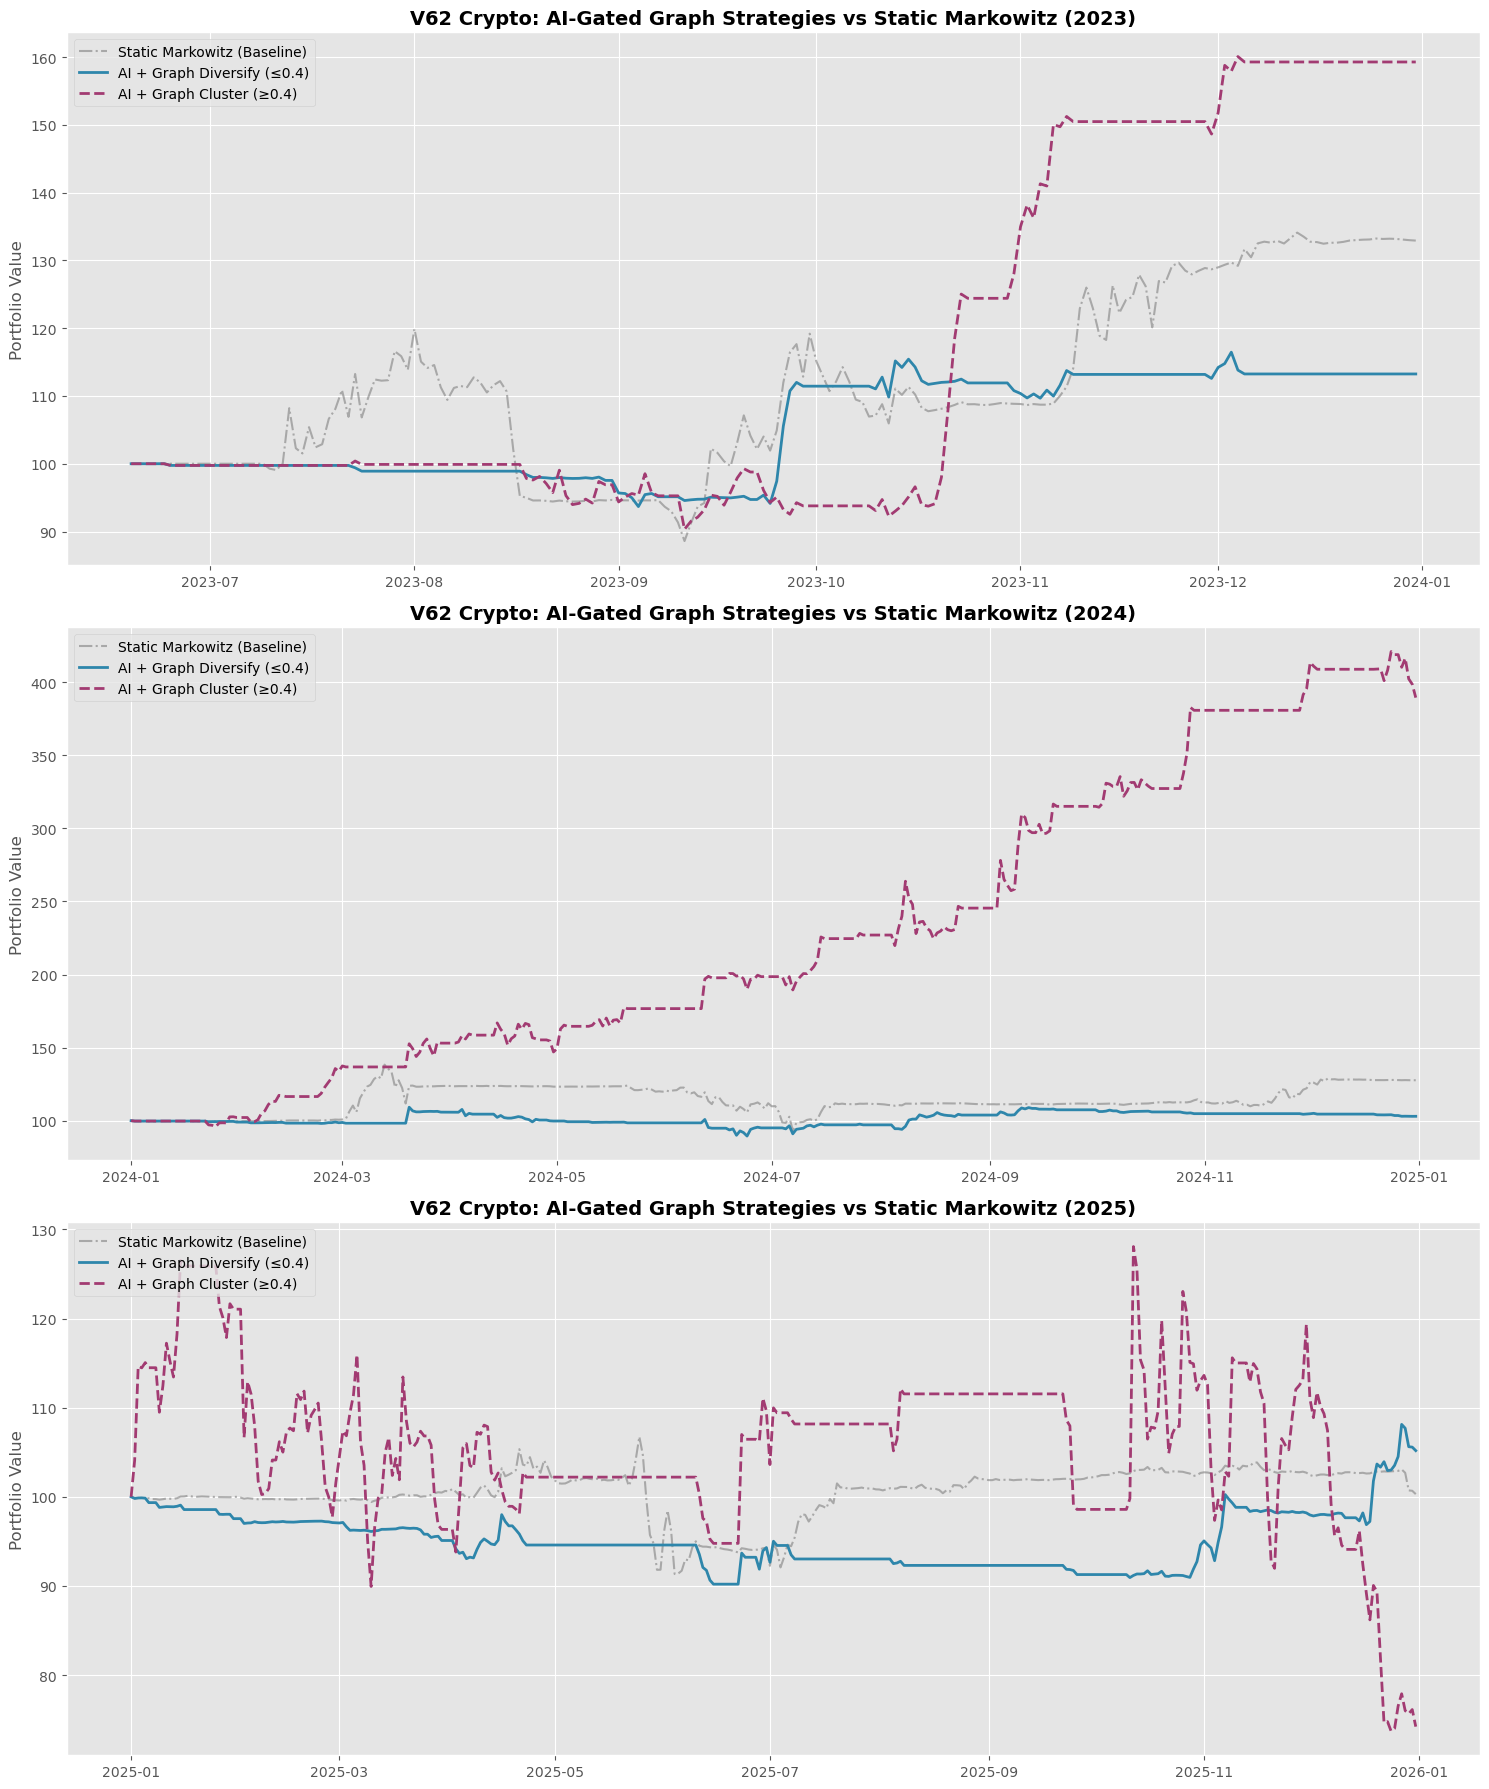

In [6]:
# Run and Plot for Each Year
years = [2023, 2024, 2025]
fig, axes = plt.subplots(3, 1, figsize=(15, 18))

for idx, year in enumerate(years):
    print(f"Processing Year: {year}...")
    year_dates = all_probs.index[all_probs.index.year == year]
    if len(year_dates) < 5: 
        print(f"Skipping {year} due to insufficient data.")
        continue
    
    # Simulations
    static_res = run_simulation_static(year_dates, returns, get_all_assets)
    div_res = run_simulation_ai_gated(year_dates, returns, all_probs, opt_t, market_index, get_assets_graph_diversify)
    clust_res = run_simulation_ai_gated(year_dates, returns, all_probs, opt_t, market_index, get_assets_graph_cluster)
    
    # Plotting
    ax = axes[idx]
    ax.plot(static_res.index, static_res['Portfolio_Value'], label='Static Markowitz (Baseline)', color='gray', linestyle='-.', alpha=0.6)
    ax.plot(div_res.index, div_res['Portfolio_Value'], label='AI + Graph Diversify (≤0.4)', color='#2E86AB', linewidth=2)
    ax.plot(clust_res.index, clust_res['Portfolio_Value'], label='AI + Graph Cluster (≥0.4)', color='#A23B72', linestyle='--', linewidth=2)
    
    ax.set_title(f"V62 Crypto: AI-Gated Graph Strategies vs Static Markowitz ({year})", fontsize=14, fontweight='bold')
    ax.set_ylabel("Portfolio Value")
    ax.legend(loc='upper left')
    
plt.tight_layout()
plt.show()